# Rabi Oscillations

## Objective

The objective of this notebook is to study the dynamics of a controlled two-level quantum system.

Unlike the previous notebook, where the evolution was entirely determined by the drift Hamiltonian, we now introduce an external control field capable of driving transitions between the computational basis states.

This phenomenon is known as Rabi oscillation and forms the basis of quantum gate implementation in many quantum computing architectures.

By the end of the notebook you should be able to demonstrate:

- Population transfer
- State control
- Rabi oscillations
- Numerical propagation of controlled quantum systems

## Controlled Hamiltonian

We consider a qubit governed by

$$
H(t)
=
\frac{\omega}{2}\sigma_z
+
u(t)\sigma_x
$$

where

- $\omega$ is the transition frequency
- $\sigma_z$ is the drift term
- $\sigma_x$ is the control term
- $u(t)$ is the control amplitude

The control field induces transitions between the states $|0\rangle$ and $|1\rangle$.

In [1]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

root_path = Path.cwd().parent
sys.path.append(str(root_path / "src"))

from hamiltonians import hamiltonian
from evolution import propagator

In [2]:
times = np.linspace(0,20,500)

def rabi_oscillations(omega, delta):
    H = hamiltonian(omega, 0.0, delta)

    psi_0 = np.array([1,0],dtype=complex)

    prob0 = []
    prob1 = []
    
    for t in times:
        U = propagator(H, t)
        psi_t = U @ psi_0
        prob0.append(np.abs(psi_t[0])**2)
        prob1.append(np.abs(psi_t[1])**2)
    return prob0, prob1

P0, P1 = rabi_oscillations(1.0, 0.5)

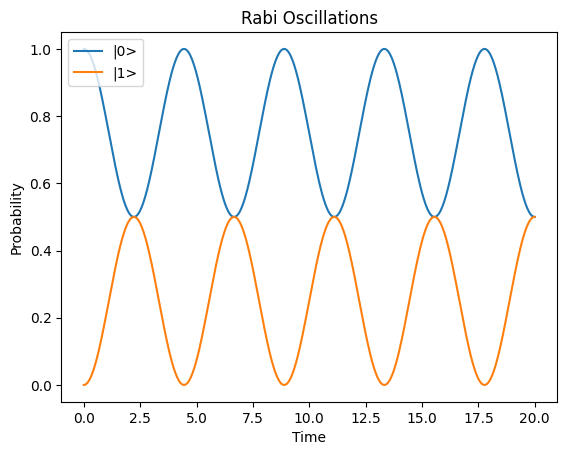

In [3]:
plt.plot(times, P0, label="|0>")
plt.plot(times, P1, label="|1>")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Rabi Oscillations")
plt.legend()

## Discussion

The oscillatory exchange of population between the states $|0\rangle$ and $|1\rangle$ is known as a Rabi oscillation.

The frequency of the oscillation depends on the strength of the applied control field.

This demonstrates that external controls can manipulate quantum states and forms the foundation of quantum gate implementation.

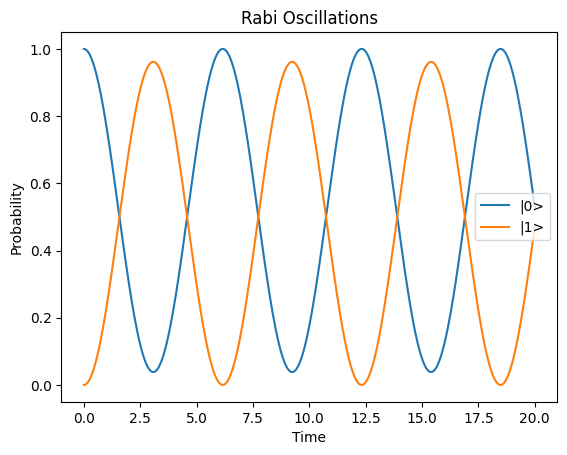

In [4]:
P0, P1 = rabi_oscillations(0.2, 0.5)

plt.plot(times, P0, label="|0>")
plt.plot(times, P1, label="|1>")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Rabi Oscillations")
plt.legend()

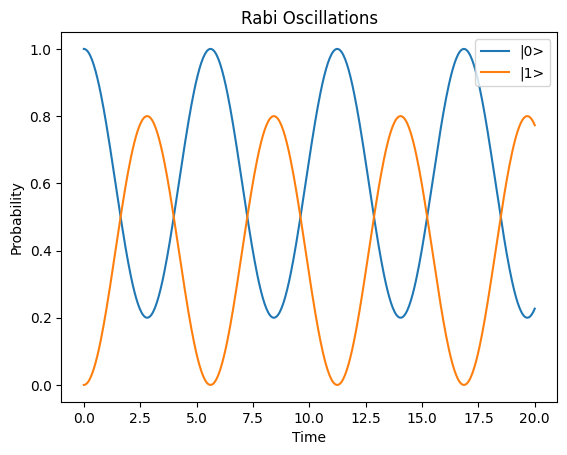

In [5]:
P0, P1 = rabi_oscillations(0.5, 0.5)

plt.plot(times, P0, label="|0>")
plt.plot(times, P1, label="|1>")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Rabi Oscillations")
plt.legend()

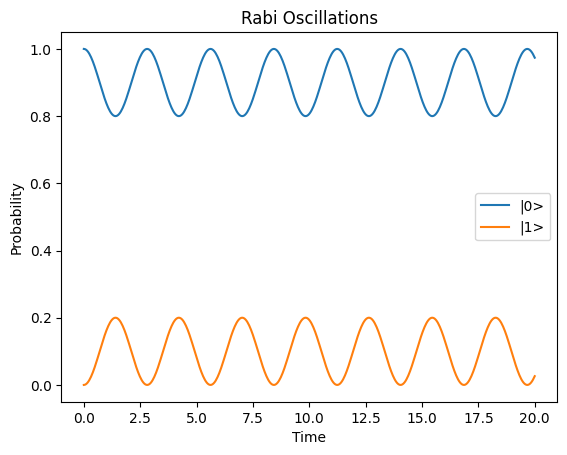

In [6]:
P0, P1 = rabi_oscillations(2.0, 0.5)

plt.plot(times, P0, label="|0>")
plt.plot(times, P1, label="|1>")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Rabi Oscillations")
plt.legend()

On the Bloch sphere, the control term

$$
\delta \sigma_x
$$

generates rotations about the x-axis.

The Rabi oscillation observed above corresponds to a rotation of the state vector on the Bloch sphere.